#### 进行小市值因子表现的全面分析

#### 第一步 导入因子分析范围的数据
##### 获取当前项目路径

In [22]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
import sys,pandas,numpy,os
from pathlib import Path
project_path = Path.cwd().parent.parent
project_path

WindowsPath('d:/360MoveData/Users/Lenovo/Desktop/cuhksz/quant_backtest_claude')

##### 将当前项目路径添加到系统路径中

In [24]:
sys.path.insert(0,str(project_path))

##### 导入数据加载器

In [25]:
from data.loader import DataManager

In [ ]:
#创建数据加载器实例
dm = DataManager()
dm.load('20250101','20251219','日线数据')
dm.load('20250101','20251219','基础指标')
dm.load('20250101','20251219',"股票基础信息")

2026-04-09 13:34:08,797 - INFO - TushareDataLoader 初始化完成，数据目录: d:\360MoveData\Users\Lenovo\Desktop\cuhksz\quant_backtest_claude\storage
2026-04-09 13:34:11,738 - INFO - 加载日线数据: 13606806 条, 5739 只股票, 3916 个交易日
2026-04-09 13:34:15,557 - INFO - 加载每日指标: 13515700 条


##### 计算因子值

In [94]:
from factor.size import MarketCapFactor
from factor.base import FactorUtils, BaseFactor
from factor.value import PEFactor, PBFactor, PSFactor, DividendYieldFactor, ValueCompositeFactor, SmallValueFactor

In [ ]:
smf = SmallValueFactor()
smf_factor_data = smf.compute(dm)
smf_factor_data.round(2)

ts_code,000001.SZ,000002.SZ,000004.SZ,000006.SZ,000007.SZ,000008.SZ,000009.SZ,000010.SZ,000011.SZ,000012.SZ,...,920964.BJ,920970.BJ,920971.BJ,920974.BJ,920976.BJ,920978.BJ,920981.BJ,920982.BJ,920985.BJ,920992.BJ
trade_date,,,,,,,,,,,,,,,,,,,,,
2025-01-02,0.48,NaN,NaN,NaN,0.41,NaN,0.30,NaN,0.6,0.55,...,0.68,NaN,0.41,0.78,0.67,0.69,0.56,0.25,0.82,0.68
2025-01-03,0.47,NaN,NaN,NaN,0.41,NaN,0.30,NaN,0.6,0.54,...,0.67,NaN,0.40,0.75,0.67,0.68,0.55,0.24,0.81,0.68
2025-01-06,0.47,NaN,NaN,NaN,0.41,NaN,0.30,NaN,0.6,0.54,...,0.71,NaN,0.41,0.75,0.68,0.68,0.55,0.23,0.80,0.68
2025-01-07,0.47,NaN,NaN,NaN,0.40,NaN,0.31,NaN,0.6,0.55,...,0.71,NaN,0.41,0.74,0.68,0.68,0.55,0.24,0.80,0.68
2025-01-08,0.47,NaN,NaN,NaN,0.40,NaN,0.31,NaN,0.6,0.55,...,0.70,NaN,0.40,0.74,0.67,0.67,0.55,0.23,0.81,0.67
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-15,0.48,NaN,NaN,NaN,0.40,NaN,0.27,0.48,NaN,NaN,...,NaN,NaN,0.45,0.81,0.66,0.50,0.58,0.23,NaN,0.68
2025-12-16,0.48,NaN,NaN,NaN,0.39,NaN,0.27,0.49,NaN,NaN,...,NaN,NaN,0.45,0.80,0.66,0.50,0.57,0.22,NaN,0.68
2025-12-17,0.48,NaN,NaN,NaN,0.40,NaN,0.27,0.48,NaN,NaN,...,NaN,NaN,0.45,0.80,0.66,0.50,0.57,0.23,NaN,0.67


#### 对因子进行分析前的预处理，纯化因子
##### 中位数处理极值
##### Z-score标准化归一化
##### 市值中性化、行业中性化

In [96]:
factor = FactorUtils().winsorize(
    smf_factor_data,
    method = 'mad'
    )

In [97]:
industry_matrix = dm.get_matrix_from_unique("股票基础信息", "industry")
#计算对数流通市值因子
macp = MarketCapFactor(negative=False)
macp_factor_data = macp.compute(dm)
factor = FactorUtils().neutralize(factor, industry_matrix, market_cap=macp_factor_data)
factor = FactorUtils().standardize(factor, method="zscore")

##### 因子值展示

In [98]:
factor.round(2)

ts_code,000001.SZ,000002.SZ,000004.SZ,000006.SZ,000007.SZ,000008.SZ,000009.SZ,000010.SZ,000011.SZ,000012.SZ,...,920964.BJ,920970.BJ,920971.BJ,920974.BJ,920976.BJ,920978.BJ,920981.BJ,920982.BJ,920985.BJ,920992.BJ
trade_date,,,,,,,,,,,,,,,,,,,,,
2025-01-02,0.65,NaN,NaN,NaN,-0.96,NaN,-0.61,NaN,1.08,1.17,...,-0.28,NaN,-1.89,0.49,0.74,0.57,-0.15,-0.99,2.09,0.25
2025-01-03,0.66,NaN,NaN,NaN,-0.99,NaN,-0.62,NaN,1.07,1.16,...,-0.33,NaN,-1.92,0.39,0.71,0.52,-0.18,-1.01,2.06,0.28
2025-01-06,0.67,NaN,NaN,NaN,-1.10,NaN,-0.60,NaN,1.05,1.17,...,-0.03,NaN,-1.86,0.41,0.73,0.52,-0.21,-1.03,2.05,0.30
2025-01-07,0.65,NaN,NaN,NaN,-1.08,NaN,-0.55,NaN,1.00,1.19,...,0.00,NaN,-1.85,0.34,0.75,0.53,-0.17,-1.03,2.09,0.28
2025-01-08,0.66,NaN,NaN,NaN,-1.04,NaN,-0.53,NaN,1.03,1.18,...,-0.10,NaN,-1.92,0.35,0.73,0.49,-0.19,-1.07,2.10,0.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-15,0.54,NaN,NaN,NaN,-0.88,NaN,-0.90,-1.49,NaN,NaN,...,NaN,NaN,-1.39,0.73,0.85,-0.34,-0.06,-0.94,NaN,0.24
2025-12-16,0.54,NaN,NaN,NaN,-0.87,NaN,-0.91,-1.48,NaN,NaN,...,NaN,NaN,-1.44,0.72,0.85,-0.36,-0.07,-0.95,NaN,0.23
2025-12-17,0.54,NaN,NaN,NaN,-0.85,NaN,-0.90,-1.52,NaN,NaN,...,NaN,NaN,-1.41,0.70,0.86,-0.36,-0.07,-0.87,NaN,0.24


In [99]:
factor[['000001.SZ','601288.SH','601988.SH','601916.SH']]

ts_code,000001.SZ,601288.SH,601988.SH,601916.SH
trade_date,,,,
2025-01-02,0.649454,1.995313,1.916470,-0.013240
2025-01-03,0.663464,2.001137,1.914669,0.003698
2025-01-06,0.666450,1.996552,1.910241,0.005424
2025-01-07,0.653529,1.990126,1.912274,0.003453
2025-01-08,0.657487,1.991776,1.916108,0.000664
...,...,...,...,...
2025-12-15,0.537194,1.991060,1.897117,-0.072690
2025-12-16,0.539361,1.989986,1.896350,-0.078427
2025-12-17,0.538772,1.997724,1.902864,-0.081038


#### 进行因子分析
##### 计算因子的IC、IR与t值
##### 绘制因子的IC、IR与t值的直方图
##### 计算因子分组收益
##### 绘制因子分组收益的直方图

In [100]:
ic = FactorUtils.calc_ic(factor, dm, lag=21)

In [101]:
ic

,ic
date,
2025-01-02,-0.060810
2025-01-03,-0.062341
2025-01-06,-0.105477
2025-01-07,-0.095925
2025-01-08,-0.069530
...,...
2025-11-14,-0.033766
2025-11-17,0.012611
2025-11-18,-0.015477


###### IC各方面
* IC均值
* IR均值
* IC的行业均值
* t值
* 多空组合收益率

In [102]:
ic_mean = ic.mean()
ic_mean

ic    0.046429
dtype: float64

###### 提取行业分类矩阵

In [103]:
industry = dm.industry
industry

ts_code,000001.SZ,000002.SZ,000004.SZ,000006.SZ,000007.SZ,000008.SZ,000009.SZ,000010.SZ,000011.SZ,000012.SZ,...,920964.BJ,920970.BJ,920971.BJ,920974.BJ,920976.BJ,920978.BJ,920981.BJ,920982.BJ,920985.BJ,920992.BJ
trade_date,,,,,,,,,,,,,,,,,,,,,
2025-01-02,银行,全国地产,软件服务,区域地产,其他商业,运输设备,电气设备,建筑工程,房产服务,玻璃,...,建筑工程,饲料,化工原料,化工原料,通信设备,汽车配件,元器件,医疗保健,电气设备,医疗保健
2025-01-03,银行,全国地产,软件服务,区域地产,其他商业,运输设备,电气设备,建筑工程,房产服务,玻璃,...,建筑工程,饲料,化工原料,化工原料,通信设备,汽车配件,元器件,医疗保健,电气设备,医疗保健
2025-01-06,银行,全国地产,软件服务,区域地产,其他商业,运输设备,电气设备,建筑工程,房产服务,玻璃,...,建筑工程,饲料,化工原料,化工原料,通信设备,汽车配件,元器件,医疗保健,电气设备,医疗保健
2025-01-07,银行,全国地产,软件服务,区域地产,其他商业,运输设备,电气设备,建筑工程,房产服务,玻璃,...,建筑工程,饲料,化工原料,化工原料,通信设备,汽车配件,元器件,医疗保健,电气设备,医疗保健
2025-01-08,银行,全国地产,软件服务,区域地产,其他商业,运输设备,电气设备,建筑工程,房产服务,玻璃,...,建筑工程,饲料,化工原料,化工原料,通信设备,汽车配件,元器件,医疗保健,电气设备,医疗保健
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-15,银行,全国地产,软件服务,区域地产,其他商业,运输设备,电气设备,建筑工程,房产服务,玻璃,...,建筑工程,饲料,化工原料,化工原料,通信设备,汽车配件,元器件,医疗保健,电气设备,医疗保健
2025-12-16,银行,全国地产,软件服务,区域地产,其他商业,运输设备,电气设备,建筑工程,房产服务,玻璃,...,建筑工程,饲料,化工原料,化工原料,通信设备,汽车配件,元器件,医疗保健,电气设备,医疗保健
2025-12-17,银行,全国地产,软件服务,区域地产,其他商业,运输设备,电气设备,建筑工程,房产服务,玻璃,...,建筑工程,饲料,化工原料,化工原料,通信设备,汽车配件,元器件,医疗保健,电气设备,医疗保健


###### 提取沪深300行业权重

In [104]:
from factor.factor_analysis.factor_tools import get_hs300_industry_weight_from_excel

w = get_hs300_industry_weight_from_excel()
print(w.head())

  industry  weight_pct  constituent_count
0       银行   11.578957                 72
1     电气设备    8.371789                 48
2      半导体    7.038975                 57
3     通信设备    6.730805                 24
4      元器件    5.698161                 48


###### 提取沪深300日线

In [105]:
from factor.factor_analysis.factor_tools import get_hs300_close_from_excel
hs300_df = get_hs300_close_from_excel("2025-01-01", "2025-12-19")
print(hs300_df)

    trade_date      close
0   2025-01-02  3820.3952
1   2025-01-03  3775.1648
2   2025-01-06  3768.9697
3   2025-01-07  3796.1055
4   2025-01-08  3789.2153
..         ...        ...
230 2025-12-15  4552.0596
231 2025-12-16  4497.5545
232 2025-12-17  4579.8750
233 2025-12-18  4552.7926
234 2025-12-19  4568.1781

[235 rows x 2 columns]


###### 绘制因子分组收益曲线

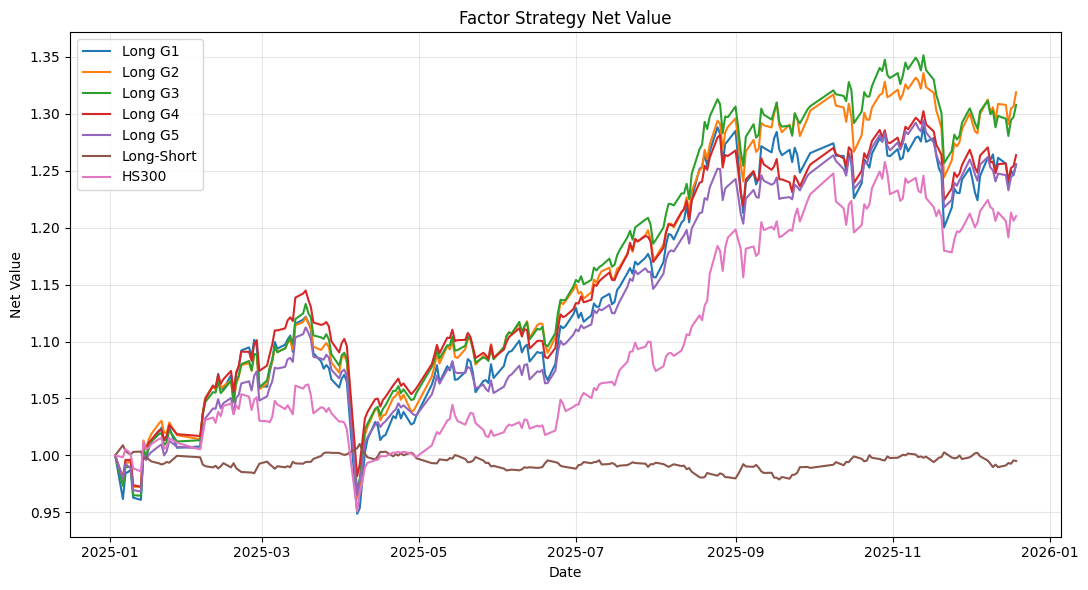

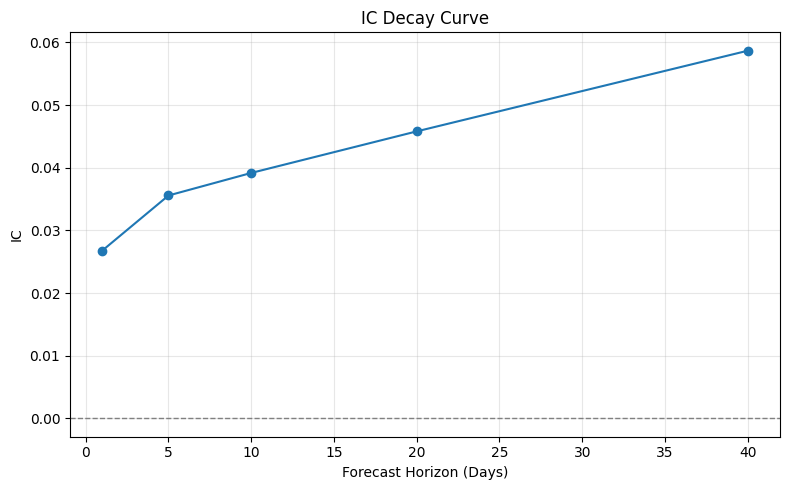

In [106]:
res = FactorUtils.calc_factor_returns(
    factor=factor,                     # TxN
    industry=industry,                 # TxN
    close=dm.price,                       # TxN
    hs300_industry_weight=w,  # Series 或 DataFrame
    hs300_index_daily=hs300_df,     # 含 close 或 pct_chg
    n_groups=5,
    factor_positive=True,
    rebalance_freq="M",
    factor_name="小市值价值因子(返回SM)",
    plot=True
)

In [107]:
import pandas as pd
df10 = pd.read_parquet(r"D:\360MoveData\Users\Lenovo\Desktop\cuhksz\quant_backtest_claude\storage\daily_basic.parquet")
df10

,ts_code,trade_date,close,turnover_rate,turnover_rate_f,volume_ratio,pe,pe_ttm,pb,ps,ps_ttm,dv_ratio,dv_ttm,total_share,float_share,free_share,total_mv,circ_mv
0,000001.SZ,2010-01-04,23.71,0.8273,0.9360,0.91,119.9115,78.7940,3.8573,5.0733,4.9464,0.0000,NaN,3.105434e+05,292411.4263,258459.8097,7.362983e+06,6.933075e+06
1,000002.SZ,2010-01-04,10.60,1.0044,1.2067,0.81,28.8977,24.7229,3.3354,2.8432,2.4284,0.4717,0.4717,1.099521e+06,965609.4910,803700.0144,1.165492e+07,1.023546e+07
2,000005.SZ,2010-01-04,5.99,2.4469,3.0649,0.57,521.6195,NaN,7.3988,50.3757,97.2610,0.0000,NaN,9.143336e+04,91374.3007,72950.2562,5.476858e+05,5.473321e+05
3,000006.SZ,2010-01-04,11.12,1.2804,1.5873,0.67,37.5442,63.7397,2.9917,5.5199,7.3921,0.7194,0.7194,5.071833e+04,49202.9652,39687.6489,5.639878e+05,5.471370e+05
4,000007.SZ,2010-01-04,6.93,1.4004,1.7893,1.01,NaN,49.0078,NaN,8.0622,9.3694,0.0000,NaN,1.849654e+04,18496.5363,14475.9137,1.281810e+05,1.281810e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13515695,920978.BJ,2026-02-13,30.04,1.7518,1.8689,NaN,39.2327,31.2238,7.4897,6.5444,5.0588,1.6753,1.6753,1.800285e+04,10093.4948,9461.0882,5.408055e+05,3.032086e+05
13515696,920981.BJ,2026-02-13,31.94,1.1182,1.6981,NaN,412.3048,453.9577,4.8188,4.6502,4.3382,0.4696,0.4696,7.646800e+03,3730.9618,2456.8096,2.442388e+05,1.191669e+05
13515697,920982.BJ,2026-02-13,217.52,0.6382,0.8016,NaN,34.1786,32.0627,13.5886,17.3472,14.3009,1.1670,1.1670,1.150653e+04,5490.5088,4371.6612,2.502901e+06,1.194295e+06
13515698,920985.BJ,2026-02-13,8.53,2.8623,4.6512,NaN,14.4876,NaN,2.4159,0.6942,0.9584,2.8801,2.8801,3.094762e+04,21931.7859,13496.7859,2.639832e+05,1.870781e+05
